# Setup

In [337]:
import os
import subprocess

# CRITICAL: Set graphviz path BEFORE importing anything else
graphviz_path = '/opt/homebrew/opt/graphviz/bin'
dot_path = os.path.join(graphviz_path, 'dot')

os.environ['PATH'] = graphviz_path + ':' + os.environ.get('PATH', '')
os.environ['GRAPHVIZ_DOT'] = dot_path

# Verify graphviz is available
try:
    result = subprocess.run([dot_path, '-V'], capture_output=True, text=True, timeout=5)
    print(f"✓ Graphviz ready: {result.stderr.strip()}")
except Exception as e:
    print(f"⚠ Warning: Graphviz check failed: {e}")

# Now import everything else
os.environ['TF_USE_LEGACY_KERAS'] = '1'

import tensorflow_decision_forests as tfdf

import numpy as np
import pandas as pd
import tensorflow as tf
import tf_keras
import math
import matplotlib.pyplot as plt

✓ Graphviz ready: dot - graphviz version 14.1.3 (20260303.0454)


In [338]:
df_Train = pd.read_csv('/Users/game./Documents/Google Data Sci/house-prices-advanced-regression-techniques/train.csv')

# EDA

In [339]:
df_Train.info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int64  
 18  OverallCond    1460

In [340]:
# See which columns have missing values and how many
missing_summary = df_Train.isnull().sum()
missing_summary = missing_summary[missing_summary > 0]
print(missing_summary)

LotFrontage      259
Alley           1369
MasVnrType       872
MasVnrArea         8
BsmtQual          37
BsmtCond          37
BsmtExposure      38
BsmtFinType1      37
BsmtFinType2      38
Electrical         1
FireplaceQu      690
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
PoolQC          1453
Fence           1179
MiscFeature     1406
dtype: int64


# Preprocess

In [341]:
df_Train = df_Train.drop(columns=['Id', 'Alley', 'MasVnrType', 'FireplaceQu', 'PoolQC', 'Fence', 'MiscFeature'])
df_Train = df_Train.dropna()

In [342]:
def get_feature(df, feature_name):
    y = df['SalePrice']
    X = df.drop(columns=['SalePrice'])
    X['MSSubClass'] = X['MSSubClass'].astype(str)
    X['MoSold'] = X['MoSold'].astype(str)
    X['YrSold'] = X['YrSold'].astype(str)
    numerical_features = X.select_dtypes(include=['int64', 'float64'])
    categorical_features = X.select_dtypes(include=['object', 'category'])
    return numerical_features, categorical_features, y

In [343]:
X_num, X_cat, y = get_feature(df_Train, 'SalePrice')

/var/folders/2m/xyjw95m92xscbmz53j7wmxq00000gp/T/ipykernel_42106/913533302.py:8: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X.select_dtypes(include=['object', 'category'])


In [344]:
len(y)

1094

# Model

In [353]:
# Prepare training and test datasets
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Encode categorical features
X_cat_encoded = X_cat.copy()
label_encoders = {}

for col in X_cat_encoded.columns:
    le = LabelEncoder()
    X_cat_encoded[col] = le.fit_transform(X_cat_encoded[col].astype(str))
    label_encoders[col] = le

# Combine numerical and categorical features
X_combined = pd.concat([X_num, X_cat_encoded], axis=1)
print(f"Combined features shape: {X_combined.shape}")
print(f"  Numerical features: {X_num.shape[1]}")
print(f"  Categorical features (encoded): {X_cat_encoded.shape[1]}")

# Split data: 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X_combined, y, test_size=0.2, random_state=42
)

print(f"\nTraining set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")

# Convert to TensorFlow datasets
BATCH_SIZE = 32

# Create training dataset
train_dataset = tf.data.Dataset.from_tensor_slices((X_train.values.astype(np.float32), y_train.values.astype(np.float32)))
train_dataset = train_dataset.shuffle(buffer_size=len(X_train))
train_dataset = train_dataset.batch(BATCH_SIZE)

# Create test dataset
test_dataset = tf.data.Dataset.from_tensor_slices((X_test.values.astype(np.float32), y_test.values.astype(np.float32)))
test_dataset = test_dataset.batch(BATCH_SIZE)

print(f"✓ Datasets prepared with batch size: {BATCH_SIZE}")

Combined features shape: (1094, 73)
  Numerical features: 33
  Categorical features (encoded): 40

Training set size: 875
Test set size: 219
✓ Datasets prepared with batch size: 32


In [354]:
# Input features - now includes both numerical and categorical
num_features = X_train.shape[1]
num_numerical = X_num.shape[1]
num_categorical = X_cat_encoded.shape[1]

print(f"Model Input Configuration:")
print(f"  Total features: {num_features}")
print(f"  Numerical features: {num_numerical}")
print(f"  Categorical features (encoded): {num_categorical}")

raw_features = tf_keras.layers.Input(shape=(num_features,))

# Stage 1
# =======

# Common learnable pre-processing with larger capacity to handle categorical data
preprocessor = tf_keras.layers.Dense(20, activation="relu")
preprocess_features = preprocessor(raw_features)

# Stage 2
# =======



# Model #1: NN
m1_z1 = tf_keras.layers.Dense(64, activation="relu")(preprocess_features)
m1_z2 = tf_keras.layers.Dense(64, activation="relu")(m1_z1)
m1_pred = tf_keras.layers.Dense(1)(m1_z2)  # NO activation for regression!

# Model #2: NN
m2_z1 = tf_keras.layers.Dense(64, activation="relu")(preprocess_features)
m2_pred = tf_keras.layers.Dense(1)(m2_z1)  # NO activation for regression!


# Model #3: DF
model_3 = tfdf.keras.RandomForestModel(num_trees=1000, random_seed=1234)
m3_pred = model_3(preprocess_features)

# Model #4: DF
model_4 = tfdf.keras.RandomForestModel(
    num_trees=1000,
    #split_axis="SPARSE_OBLIQUE", # Uncomment this line to increase the quality of this model
    random_seed=4567)
m4_pred = model_4(preprocess_features)

# Model #5: Additional NN with ReLU activation
m5_z1 = tf_keras.layers.Dense(100, activation="relu")(preprocess_features)
m5_z2 = tf_keras.layers.Dense(64, activation="relu")(m5_z1)
m5_pred = tf_keras.layers.Dense(1)(m5_z2)  # NO activation for regression

# Since TF-DF uses deterministic learning algorithms, you should set the model's
# training seed to different values otherwise both
# `tfdf.keras.RandomForestModel` will be exactly the same.

# Stage 3: Ensemble Averaging
# ============================
# Ensemble with 3 NN models
mean_nn_only = tf.reduce_mean(tf.stack([m1_pred, m2_pred, m5_pred], axis=0), axis=0)

# Full ensemble with all 5 models (3 NNs + 2 Tree models trained separately)
mean_nn_and_df = tf.reduce_mean(
    tf.stack([m1_pred, m2_pred, m5_pred, m3_pred, m4_pred], axis=0), axis=0)

# Keras Models
# ============

ensemble_nn_only = tf_keras.models.Model(raw_features, mean_nn_only)
ensemble_nn_and_df = tf_keras.models.Model(raw_features, mean_nn_and_df)

Model Input Configuration:
  Total features: 73
  Numerical features: 33
  Categorical features (encoded): 40
Use /var/folders/2m/xyjw95m92xscbmz53j7wmxq00000gp/T/tmp8ur7y296 as temporary training directory


Use /var/folders/2m/xyjw95m92xscbmz53j7wmxq00000gp/T/tmp3imombq0 as temporary training directory


In [355]:
%%time

# Train NN Ensemble
print("="*60)
print("Training Full Ensemble (3 NNs + 2 Random Forests)")
print("="*60)

# 1. Compile for Regression
ensemble_nn_and_df.compile(
    optimizer=tf_keras.optimizers.legacy.Adam(),  # Use legacy for Mac M1
    loss=tf_keras.losses.MeanSquaredError(),
    metrics=[tf_keras.metrics.MeanAbsoluteError()]
)

# 2. Fit the model - Train the NN portion (m1, m2, m5)
print("\nTraining ensemble_nn_and_df (NN portion: m1, m2, m5)...")
ensemble_nn_and_df.fit(
    train_dataset, 
    epochs=100,  # Reduced from 100 for faster training
    validation_data=test_dataset,
    verbose=1
)

Training Full Ensemble (3 NNs + 2 Random Forests)

Training ensemble_nn_and_df (NN portion: m1, m2, m5)...
Epoch 1/100


28/28 [==============================] - 0s 3ms/step - loss: 41275031552.0000 - mean_absolute_error: 185917.2969 - val_loss: 41835433984.0000 - val_mean_absolute_error: 185386.4062
Epoch 2/100
28/28 [==============================] - 0s 3ms/step - loss: 41275031552.0000 - mean_absolute_error: 185917.2969 - val_loss: 41835433984.0000 - val_mean_absolute_error: 185386.4062
Epoch 2/100
28/28 [==============================] - 0s 1ms/step - loss: 38852890624.0000 - mean_absolute_error: 179790.4062 - val_loss: 37283704832.0000 - val_mean_absolute_error: 173476.8438
Epoch 3/100
28/28 [==============================] - 0s 1ms/step - loss: 38852890624.0000 - mean_absolute_error: 179790.4062 - val_loss: 37283704832.0000 - val_mean_absolute_error: 173476.8438
Epoch 3/100
28/28 [==============================] - 0s 1ms/step - loss: 29336147968.0000 - mean_absolute_error: 152439.7188 - val_loss: 21681885184.0000 - val_mean_absolute_error: 124586.0312
Epoch 4/100
28/28 [============================

# Eval

In [356]:
# Evaluation on Test Set
print("\n" + "=" * 60)
print("MODEL EVALUATION ON TEST SET")
print("=" * 60)

# Evaluate the model on test dataset
test_loss, test_mae = ensemble_nn_and_df.evaluate(test_dataset, verbose=0)

print(f"\nTest Results:")
print(f"  Loss (MSE): ${test_loss:,.2f}")
print(f"  MAE: ${test_mae:,.2f}")

# Make predictions on test set
y_pred_test = ensemble_nn_and_df.predict(test_dataset, verbose=0)

# Calculate additional metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Flatten predictions
y_pred_test_flat = y_pred_test.flatten()

# Calculate metrics
mse = mean_squared_error(y_test, y_pred_test_flat)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred_test_flat)
r2 = r2_score(y_test, y_pred_test_flat)

print(f"\nDetailed Metrics:")
print(f"  RMSE: ${rmse:,.2f}")
print(f"  MAE: ${mae:,.2f}")
print(f"  R² Score: {r2:.4f}")
print(f"  Mean Price (Test): ${y_test.mean():,.2f}")

# Show sample predictions
print(f"\nSample Predictions vs Actual:")
print("-" * 60)
comparison = pd.DataFrame({
    'Actual': y_test.values[:10],
    'Predicted': y_pred_test_flat[:10],
    'Error': np.abs(y_test.values[:10] - y_pred_test_flat[:10])
})
print(comparison.to_string(index=False))
print("\n" + "=" * 60)


MODEL EVALUATION ON TEST SET

Test Results:
  Loss (MSE): $2,075,113,344.00
  MAE: $31,791.08

Detailed Metrics:
  RMSE: $45,553.41
  MAE: $31,791.08
  R² Score: 0.7241
  Mean Price (Test): $187,835.28

Sample Predictions vs Actual:
------------------------------------------------------------
 Actual     Predicted        Error
 144000 161985.718750 17985.718750
 127000 111645.609375 15354.390625
 155000 147399.000000  7601.000000
 119000 117921.500000  1078.500000
 140000 112005.726562 27994.273438
 193000 198175.703125  5175.703125
  76000  93912.875000 17912.875000
 253293 304609.093750 51316.093750
 185000 158623.406250 26376.593750
 239799 232995.421875  6803.578125



In [349]:
y_pred_test = y_pred_test.reshape(-1)

(array([[ 7., 15., 30., 41., 27., 25., 12., 19.,  9., 10.,  5.,  6.,  5.,
          2.,  2.,  1.,  1.,  0.,  1.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
          0.,  0.,  0.,  1.],
        [ 2.,  6., 27., 29., 44., 29., 33., 20., 14.,  3.,  8.,  1.,  1.,
          1.,  0.,  0.,  0.,  0.,  0.,  1.,  0.,  0.,  0.,  0.,  0.,  0.,
          0.,  0.,  0.,  0.]]),
 array([ 60000.        ,  83166.66666667, 106333.33333333, 129500.        ,
        152666.66666667, 175833.33333333, 199000.        , 222166.66666667,
        245333.33333333, 268500.        , 291666.66666667, 314833.33333333,
        338000.        , 361166.66666667, 384333.33333333, 407500.        ,
        430666.66666667, 453833.33333333, 477000.        , 500166.66666667,
        523333.33333333, 546500.        , 569666.66666667, 592833.33333333,
        616000.        , 639166.66666667, 662333.33333333, 685500.        ,
        708666.66666667, 731833.33333333, 755000.        ]),
 <a list of 2 BarContainer objects>)

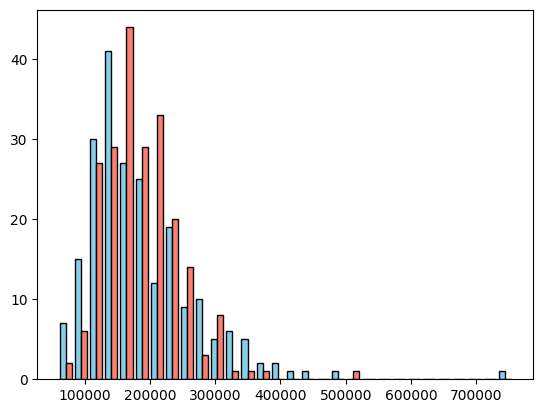

In [350]:
import matplotlib.pyplot as plt
import numpy as np
plt.hist([y_test, y_pred_test], bins=30, color=['skyblue', 'salmon'], edgecolor='black', label=['Actual', 'Predicted'])

# Submission

In [358]:
# Load test data and prepare for submission
print("=" * 70)
print("KAGGLE SUBMISSION PREPARATION (WITH CATEGORICAL FEATURES)")
print("=" * 70)

# 1. Load test data
test_df = pd.read_csv('/Users/game./Documents/Google Data Sci/house-prices-advanced-regression-techniques/test.csv')
print(f"\n✓ Test data loaded: {test_df.shape[0]} samples, {test_df.shape[1]} columns")

# 2. Load sample submission
sample_submission = pd.read_csv('/Users/game./Documents/Google Data Sci/house-prices-advanced-regression-techniques/sample_submission.csv')
print(f"✓ Sample submission loaded: {sample_submission.shape[0]} rows")
print(f"  Columns: {sample_submission.columns.tolist()}")

# 3. Apply same preprocessing to test data
test_df_processed = test_df.drop(columns=['Id', 'Alley', 'MasVnrType', 'FireplaceQu', 'PoolQC', 'Fence', 'MiscFeature'], errors='ignore')

# 4. Extract numerical features
test_num = test_df_processed[X_num.columns].copy()

# Handle missing values in numerical features (fill with mean from training)
for col in test_num.columns:
    if test_num[col].isnull().any():
        test_num[col] = test_num[col].fillna(X_num[col].mean())

# 5. Extract and encode categorical features
test_cat = test_df_processed.select_dtypes(include=['object', 'category']).copy()
test_cat_encoded = test_cat.copy()

for col in test_cat_encoded.columns:
    if col in label_encoders:
        # Handle unknown categories by using the first class (safe default)
        test_cat_encoded[col] = test_cat_encoded[col].apply(
            lambda x: label_encoders[col].transform([str(x)])[0] 
            if str(x) in label_encoders[col].classes_ 
            else 0
        )
    else:
        test_cat_encoded[col] = 0

# 6. Align test categorical features to match training set columns
for col in X_cat_encoded.columns:
    if col not in test_cat_encoded.columns:
        test_cat_encoded[col] = 0

# Ensure same column order as training
test_cat_encoded = test_cat_encoded[X_cat_encoded.columns]

# 7. Combine numerical and categorical features
test_features_combined = pd.concat([test_num, test_cat_encoded], axis=1)
print(f"\n✓ Test features prepared: {test_features_combined.shape}")
print(f"  Numerical: {test_num.shape[1]}, Categorical (encoded): {test_cat_encoded.shape[1]}")
print(f"  Matches training shape: {test_features_combined.shape[1] == X_train.shape[1]}")

# 8. Create TensorFlow dataset for predictions
test_submission_dataset = tf.data.Dataset.from_tensor_slices(test_features_combined.values.astype(np.float32))
test_submission_dataset = test_submission_dataset.batch(BATCH_SIZE)

# 9. Make predictions
print(f"\nMaking predictions on test set...")
y_pred_submission = ensemble_nn_and_df.predict(test_submission_dataset, verbose=0)
y_pred_submission = y_pred_submission.flatten()

# Handle any remaining NaN values
y_pred_submission = np.nan_to_num(y_pred_submission, nan=y_train.mean())

print(f"✓ Predictions made: {len(y_pred_submission)} predictions")
print(f"  Min: ${y_pred_submission.min():,.2f}")
print(f"  Max: ${y_pred_submission.max():,.2f}")
print(f"  Mean: ${y_pred_submission.mean():,.2f}")
print(f"  NaN count: {np.isnan(y_pred_submission).sum()}")

# 10. Create submission dataframe
submission = sample_submission.copy()
submission['SalePrice'] = y_pred_submission

print(f"\n✓ Submission dataframe created:")
print(submission.head(10))

# 11. Save submission
submission_path = '/Users/game./Documents/Google Data Sci/submission.csv'
submission.to_csv(submission_path, index=False)
print(f"\n✓ Submission saved to: {submission_path}")
print(f"  Total predictions: {len(submission)}")
print(f"  File size: {os.path.getsize(submission_path) / 1024:.2f} KB")
print("\n" + "=" * 70)

KAGGLE SUBMISSION PREPARATION (WITH CATEGORICAL FEATURES)

✓ Test data loaded: 1459 samples, 80 columns
✓ Sample submission loaded: 1459 rows
  Columns: ['Id', 'SalePrice']


/var/folders/2m/xyjw95m92xscbmz53j7wmxq00000gp/T/ipykernel_42106/3029311183.py:27: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  test_cat = test_df_processed.select_dtypes(include=['object', 'category']).copy()



✓ Test features prepared: (1459, 73)
  Numerical: 33, Categorical (encoded): 40
  Matches training shape: True

Making predictions on test set...
✓ Predictions made: 1459 predictions
  Min: $31,543.09
  Max: $610,896.69
  Mean: $174,565.61
  NaN count: 0

✓ Submission dataframe created:
     Id      SalePrice
0  1461  143237.328125
1  1462  105372.234375
2  1463  185105.437500
3  1464  192827.046875
4  1465  174766.843750
5  1466  171804.218750
6  1467  178357.281250
7  1468  149838.625000
8  1469  179481.156250
9  1470  137839.328125

✓ Submission saved to: /Users/game./Documents/Google Data Sci/submission.csv
  Total predictions: 1459
  File size: 21.05 KB

